# Exploratory Data Analysis

### Import the required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### Load the data

In [3]:
df = pd.read_csv('../data/OnlineNewsPopularityCleaned.csv')

df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_shares,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028573,0.419300,0.494651,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,16000.0,3151.157895,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028633,0.028794,0.028575,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Analysis of Target Variable Distribution and Impact of Log Transformation

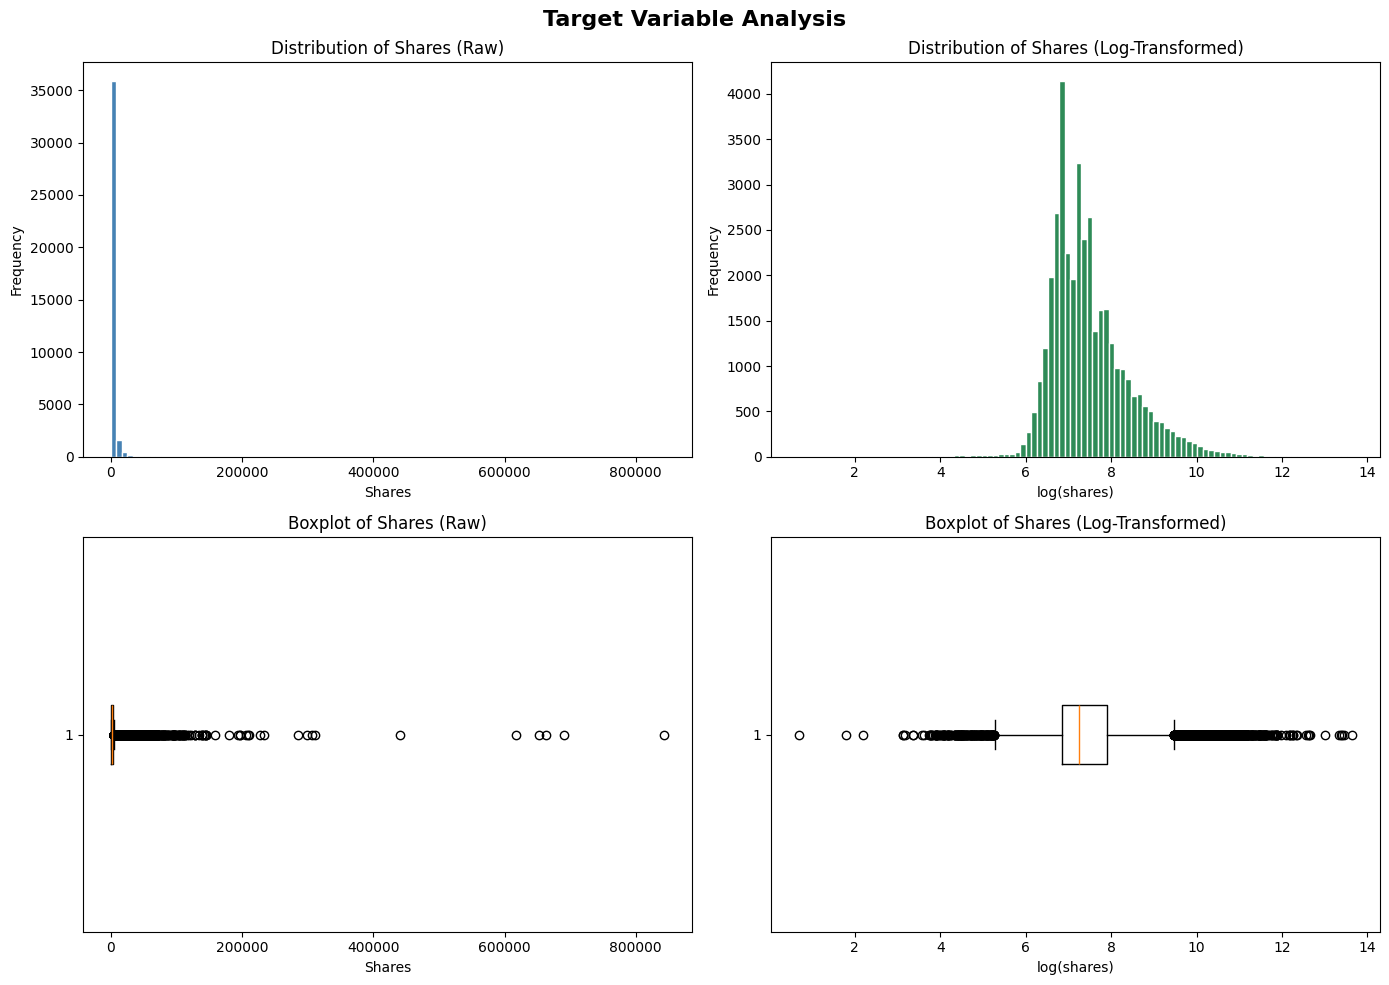

Skewness: 34.95283625338533


In [4]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Raw shares distribution
axes[0, 0].hist(df['shares'], bins=100, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Shares (Raw)')
axes[0, 0].set_xlabel('Shares')
axes[0, 0].set_ylabel('Frequency')

# Plot 2 — Log-transformed shares distribution
axes[0, 1].hist(np.log1p(df['shares']), bins=100, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Distribution of Shares (Log-Transformed)')
axes[0, 1].set_xlabel('log(shares)')
axes[0, 1].set_ylabel('Frequency')

# Plot 3 — Boxplot of raw shares
axes[1, 0].boxplot(df['shares'], vert=False)
axes[1, 0].set_title('Boxplot of Shares (Raw)')
axes[1, 0].set_xlabel('Shares')

# Plot 4 — Boxplot of log shares
axes[1, 1].boxplot(np.log1p(df['shares']), vert=False)
axes[1, 1].set_title('Boxplot of Shares (Log-Transformed)')
axes[1, 1].set_xlabel('log(shares)')

plt.tight_layout()
plt.show()

skewness = df['shares'].skew()
print("Skewness:", skewness)

### Top 20 Features Correlated with Target Variable (shares)

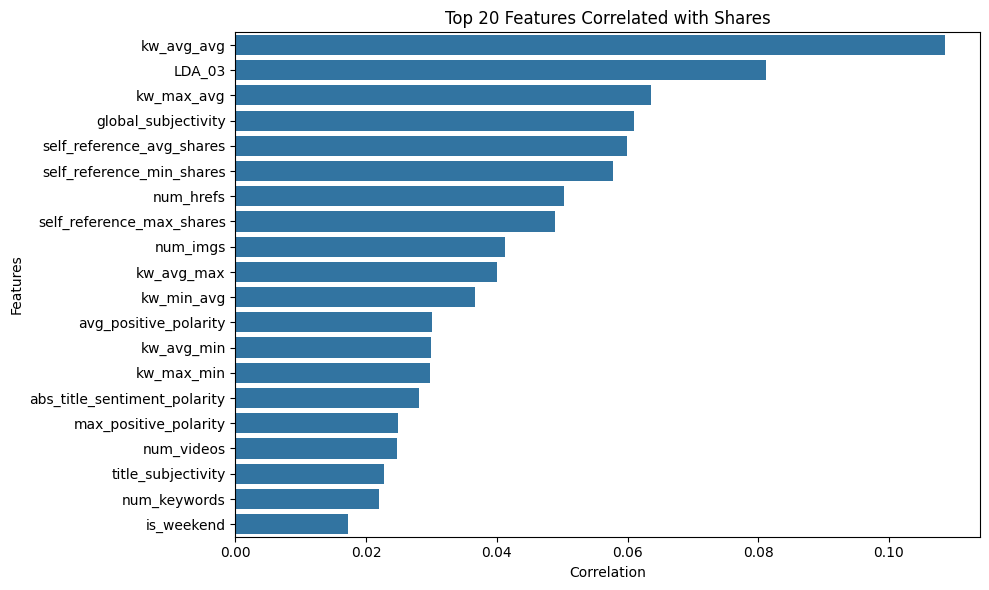

In [5]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

corr_with_target = numeric_df.corr()['shares'].sort_values(ascending=False)

# Drop self-correlation
corr_with_target = corr_with_target.drop('shares')

# Take top 20 positive correlations
top_corr = corr_with_target.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title('Top 20 Features Correlated with Shares')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

### Top 10 Positive and Negative Feature Correlations with Shares

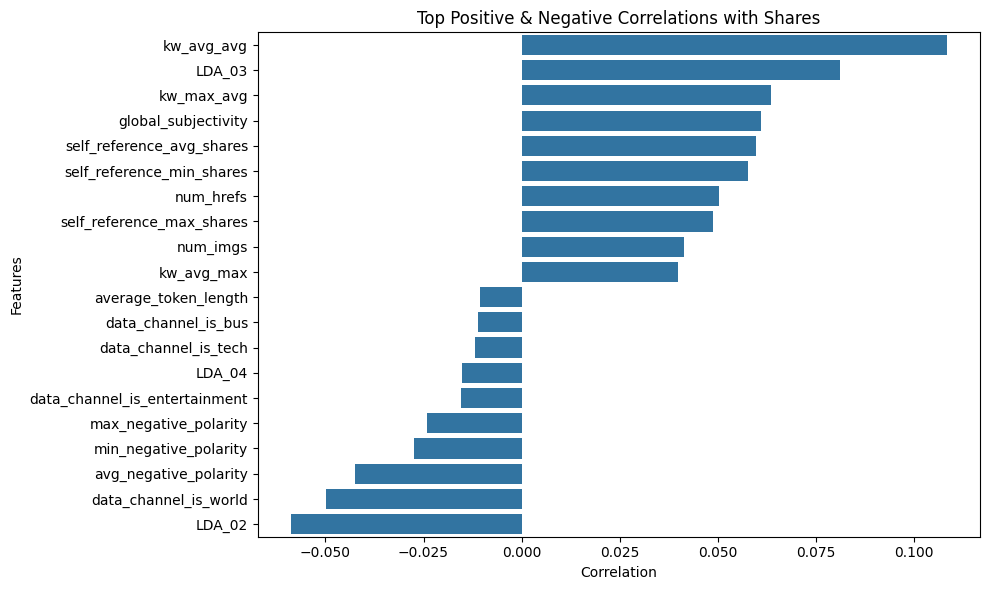

In [6]:
top_pos = corr_with_target.head(10)
top_neg = corr_with_target.tail(10)

combined = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 6))
sns.barplot(x=combined.values, y=combined.index)

plt.title('Top Positive & Negative Correlations with Shares')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

### Top 10 negative and positve correlations with target variable

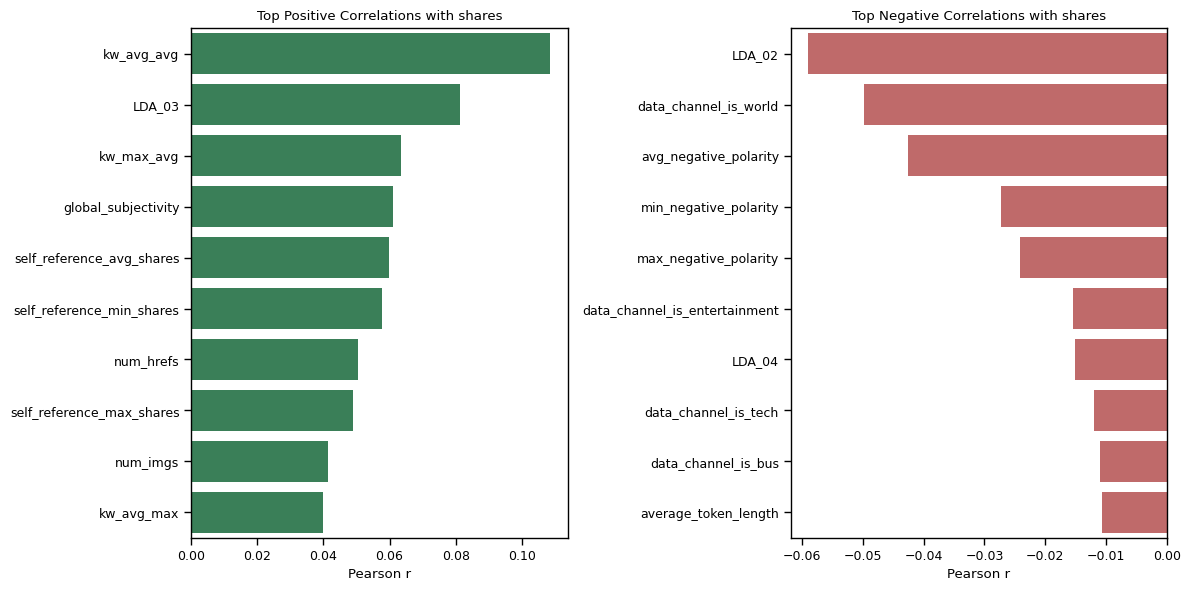

In [7]:
sns.set_context("paper")

# 3. Sort correlations
corr_sorted = corr_with_target.sort_values()

# 4. Select top features
top_neg = corr_sorted.head(10)                  # most negative
top_pos = corr_sorted.tail(10).iloc[::-1]      # most positive

# 5. Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Positive correlations
sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], color='seagreen')
axes[0].set_title('Top Positive Correlations with shares')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('')
axes[0].tick_params(labelsize=9)

# Negative correlations
sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], color='indianred')
axes[1].set_title('Top Negative Correlations with shares')
axes[1].set_xlabel('Pearson r')
axes[1].set_ylabel('')
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### Pairwise Pearson Correlations Between Numerical Features

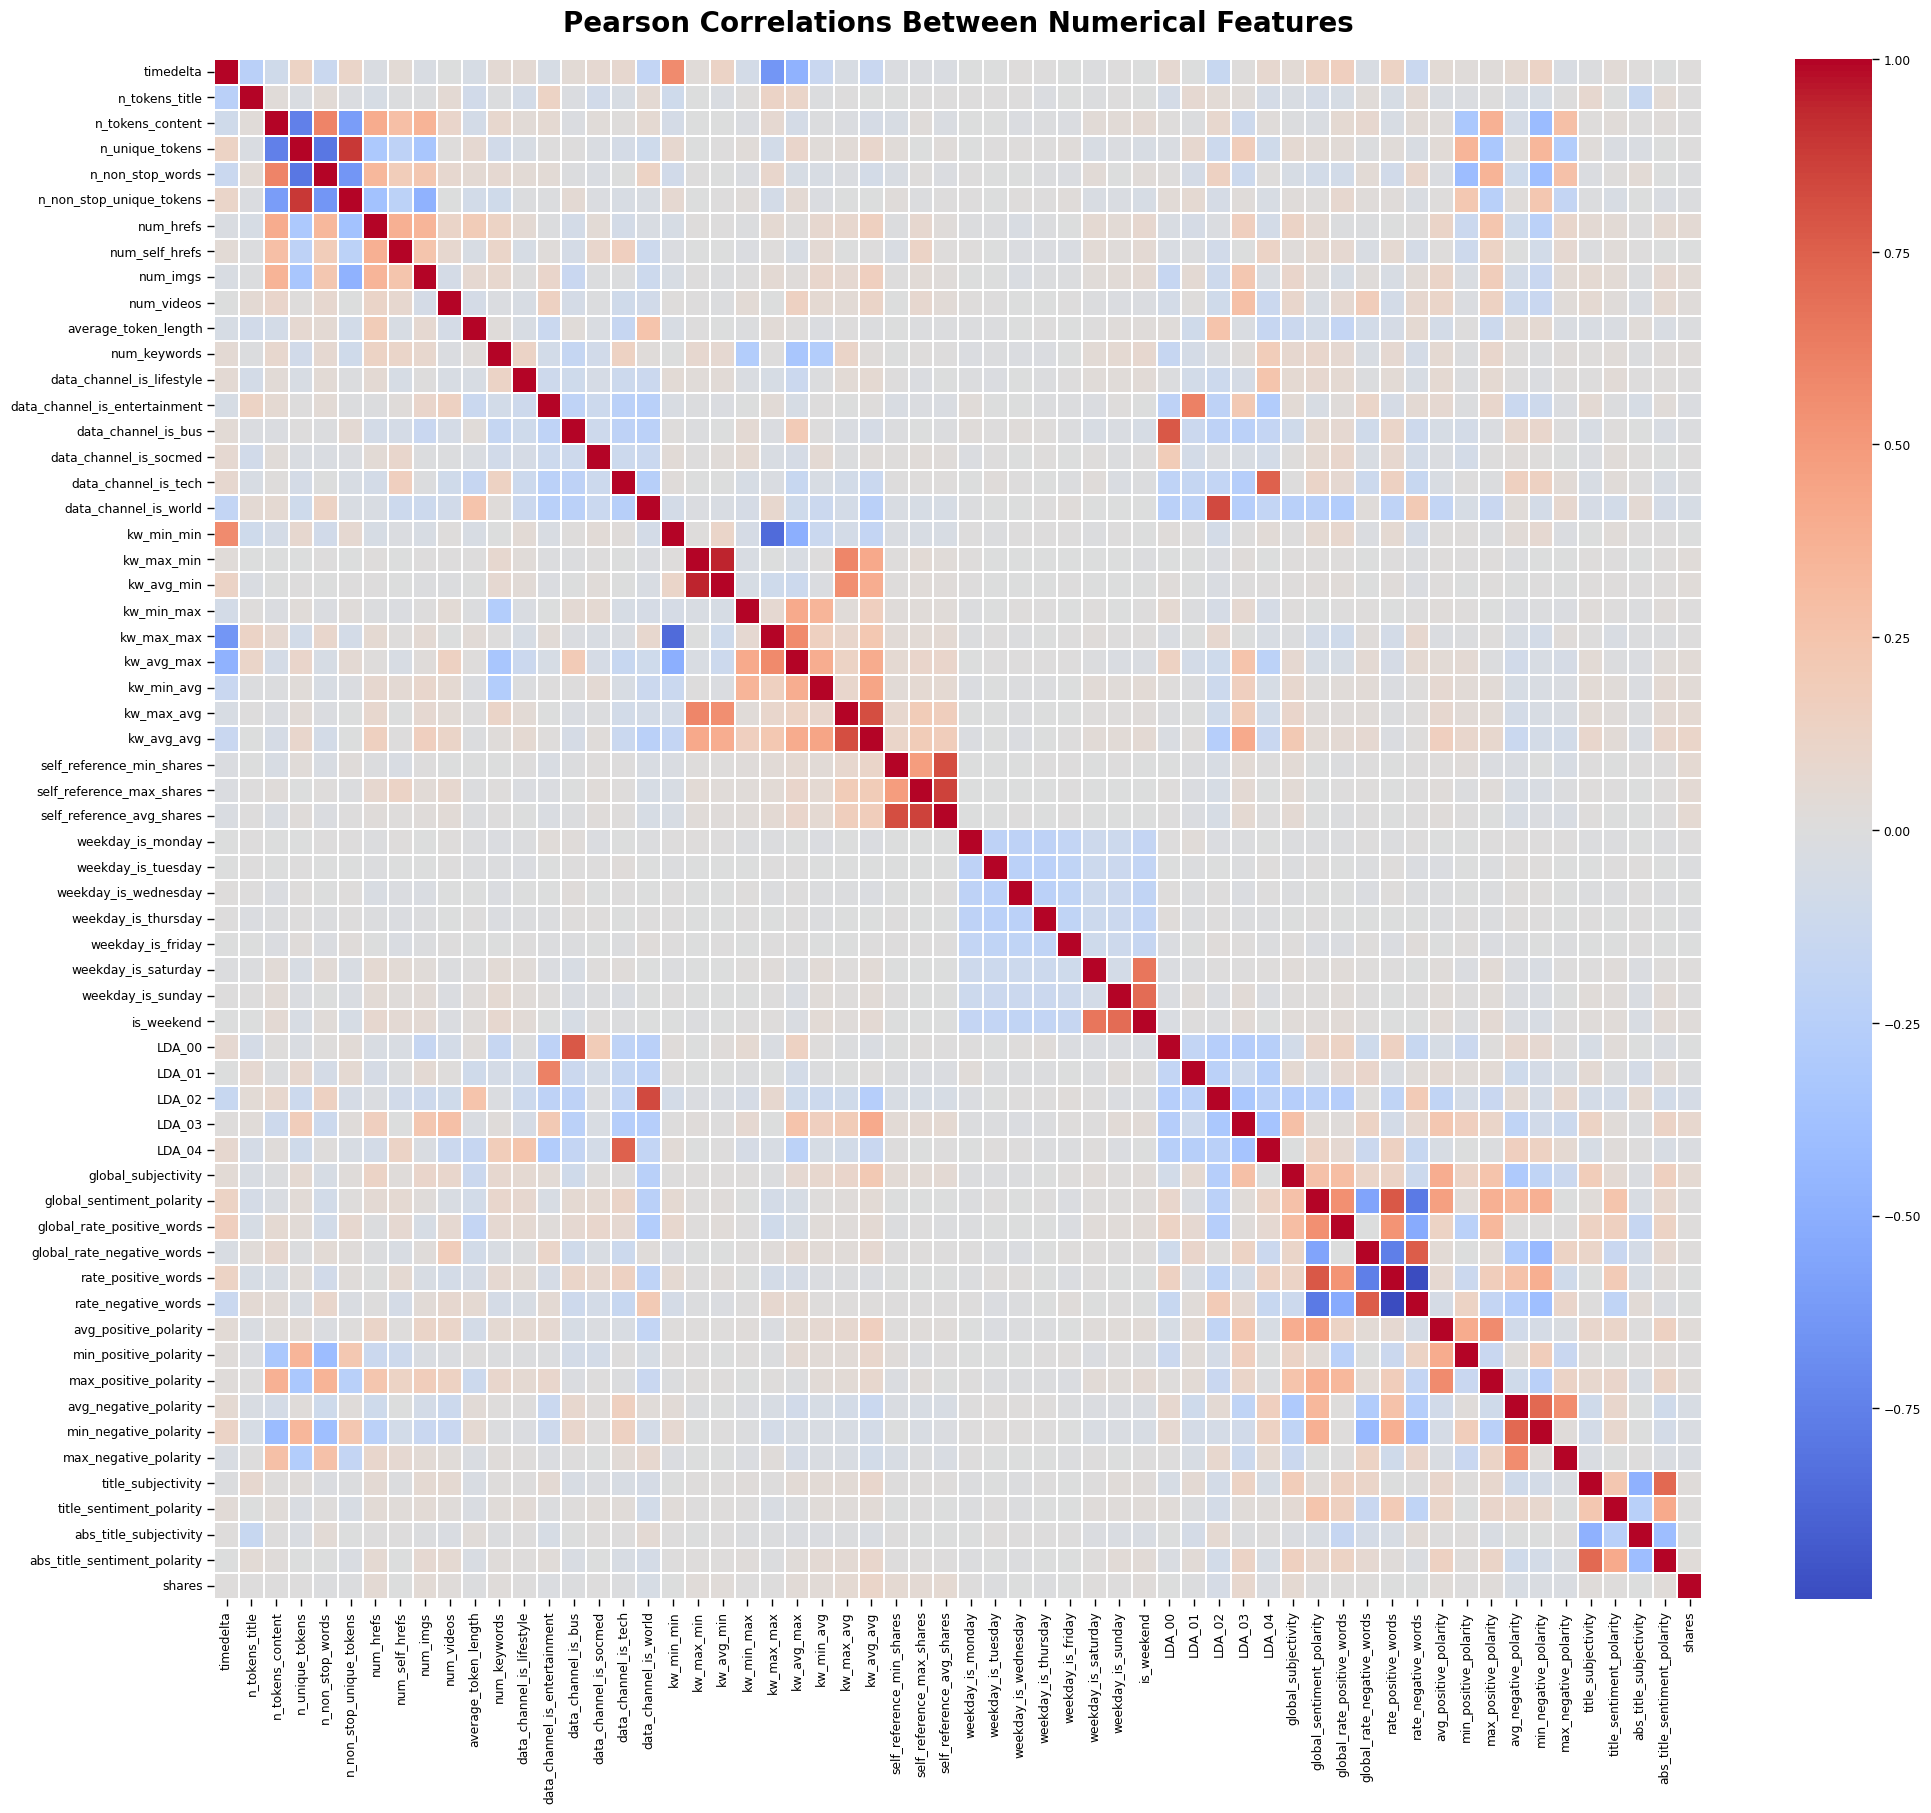

In [8]:
plt.figure(figsize=(24, 20))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title(
    'Pearson Correlations Between Numerical Features',
    fontsize=20,
    fontweight='bold',
    pad=20  
)

plt.show()

In [14]:
corr_matrix = numeric_df.corr()

pairs_to_check = [
    ('rate_negative_words', 'rate_positive_words'),
    ('kw_max_min', 'kw_avg_min'),
    ('kw_max_avg', 'kw_avg_avg'),
    ('n_non_stop_unique_tokens', 'n_unique_tokens'),
    ('self_reference_min_shares', 'self_reference_avg_shares'),
    ('self_reference_max_shares', 'self_reference_avg_shares')
]

for f1, f2 in pairs_to_check:
    corr_value = corr_matrix.loc[f1, f2]
    print(f"{f1} vs {f2}: r = {corr_value:.3f}")

rate_negative_words vs rate_positive_words: r = -0.997
kw_max_min vs kw_avg_min: r = 0.940
kw_max_avg vs kw_avg_avg: r = 0.816
n_non_stop_unique_tokens vs n_unique_tokens: r = 0.885
self_reference_min_shares vs self_reference_avg_shares: r = 0.819
self_reference_max_shares vs self_reference_avg_shares: r = 0.853


### Tabular Analysis of Strong Pairwise Feature Correlations (|r| > 0.8)

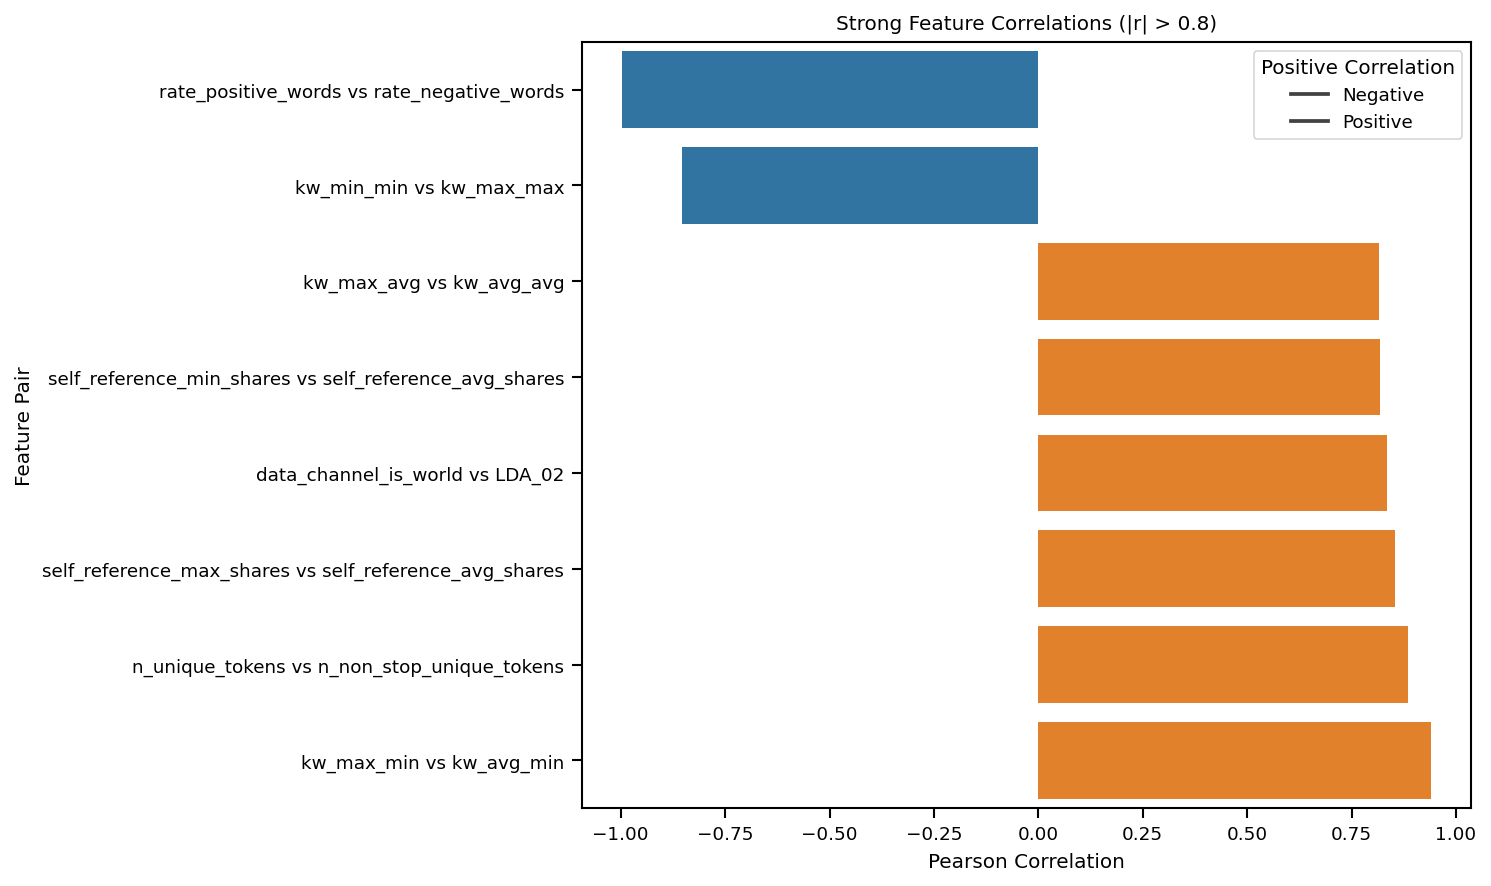

In [ ]:
# Upper triangle only (avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Convert to table format
corr_table = (
    upper.stack()
    .reset_index()
)

corr_table.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Filter strong correlations
corr_table = corr_table[
    corr_table['Correlation'].abs() > 0.8
].sort_values(by='Correlation', key=abs, ascending=False)

corr_table.style\
    .format({"Correlation": "{:.2f}"})\
    .background_gradient(cmap='coolwarm')

corr_plot = corr_table.copy()
corr_plot['Feature Pair'] = corr_plot['Feature 1'] + ' vs ' + corr_plot['Feature 2']
corr_plot = corr_plot.sort_values(by='Correlation')

plt.figure(figsize=(10, 6))

sns.barplot(
    data=corr_plot,
    x='Correlation',
    y='Feature Pair',
    hue=corr_plot['Correlation'] > 0,  # True = positive, False = negative
    dodge=False
)

plt.title('Strong Feature Correlations (|r| > 0.8)')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature Pair')
plt.legend(title='Positive Correlation', labels=['Negative', 'Positive'])

plt.tight_layout()
plt.show()

 ## Feature Distributions

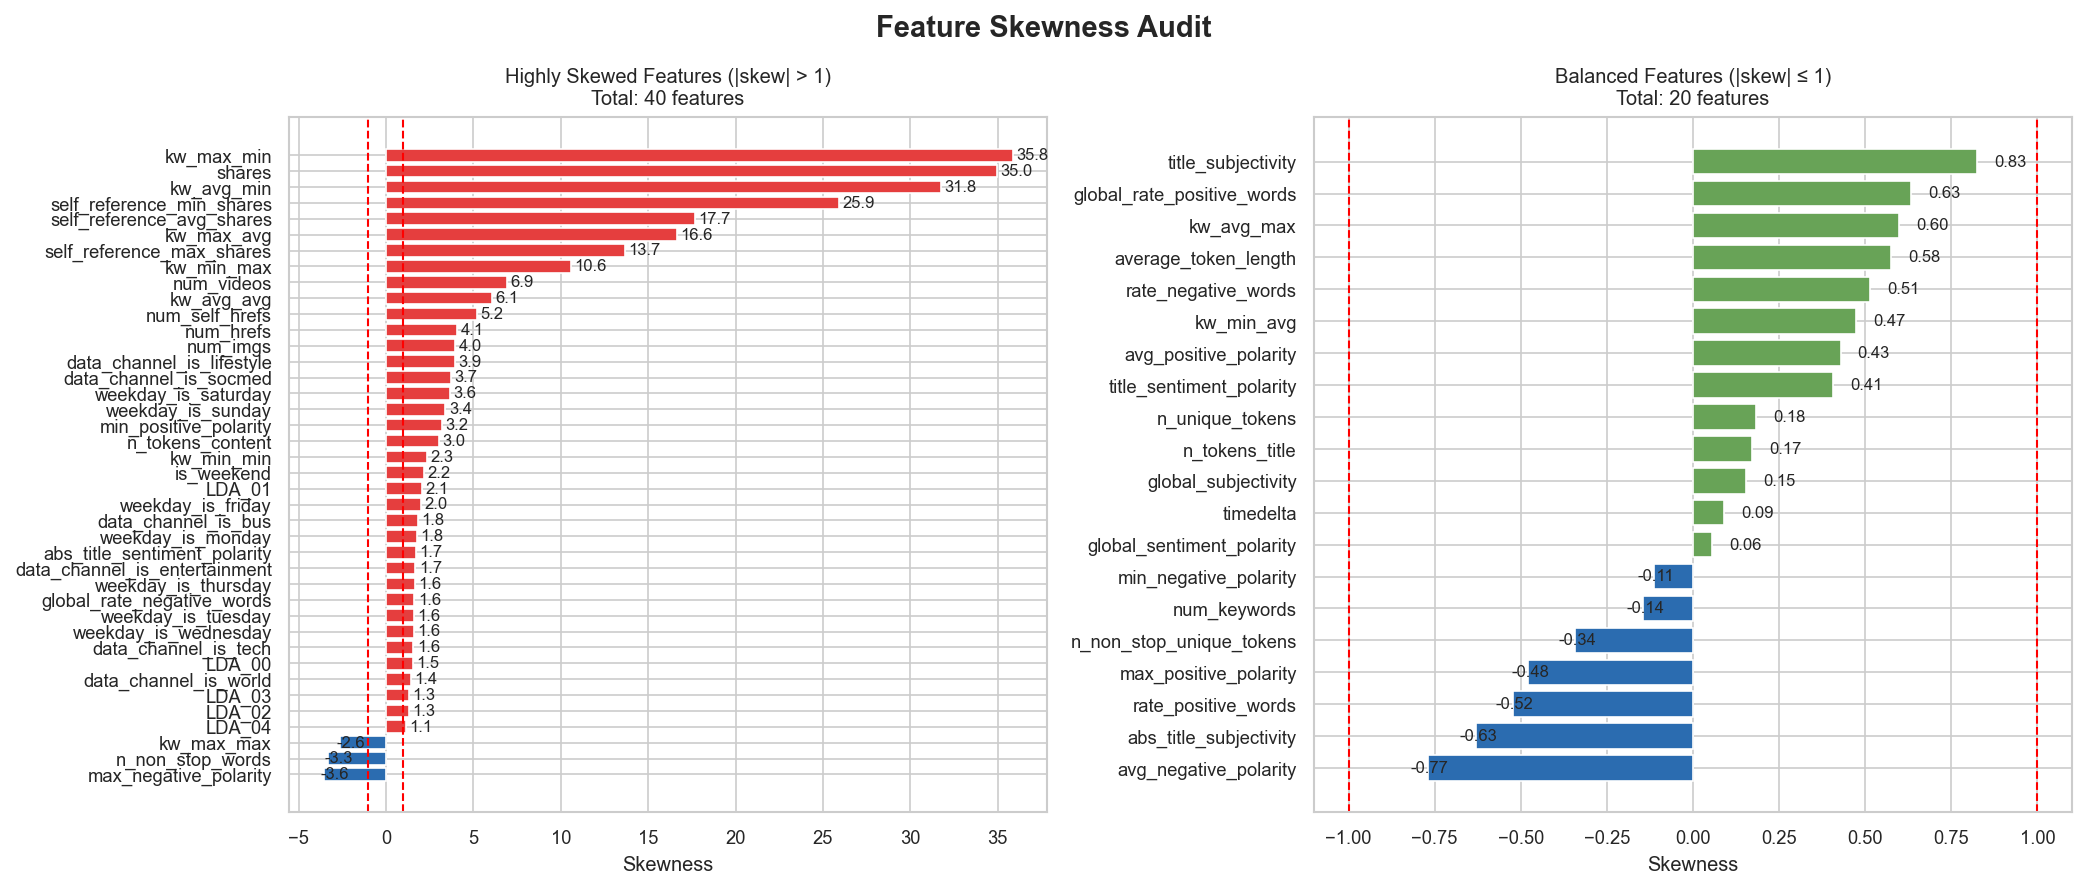

In [ ]:
sns.set_style("whitegrid")
sns.set_context("paper")

# --- Step 1: Compute skewness ---
skew_values = df.skew(numeric_only=True)

# --- Step 2: Split ---
high_skew = skew_values[skew_values.abs() > 1].sort_values()
balanced_skew = skew_values[skew_values.abs() <= 1].sort_values()

# Convert to DataFrame
high_df = high_skew.reset_index()
high_df.columns = ['Feature', 'Skewness']

balanced_df = balanced_skew.reset_index()
balanced_df.columns = ['Feature', 'Skewness']

# --- Step 3: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- LEFT: HIGH SKEW ----------------
colors_high = ['#2b6cb0' if x < 0 else '#e53e3e' for x in high_df['Skewness']]

axes[0].barh(high_df['Feature'], high_df['Skewness'], color=colors_high)
axes[0].set_title(f'Highly Skewed Features (|skew| > 1)\nTotal: {len(high_df)} features')
axes[0].set_xlabel('Skewness')

# Value labels
for i, v in enumerate(high_df['Skewness']):
    axes[0].text(v + 0.2 if v > 0 else v - 0.2, i, f'{v:.1f}', va='center', fontsize=8)

# Threshold lines
axes[0].axvline(1, color='red', linestyle='--', linewidth=1)
axes[0].axvline(-1, color='red', linestyle='--', linewidth=1)

# ---------------- RIGHT: BALANCED ----------------
colors_bal = ['#2b6cb0' if x < 0 else '#68a357' for x in balanced_df['Skewness']]

axes[1].barh(balanced_df['Feature'], balanced_df['Skewness'], color=colors_bal)
axes[1].set_title(f'Balanced Features (|skew| ≤ 1)\nTotal: {len(balanced_df)} features')
axes[1].set_xlabel('Skewness')

# Value labels
for i, v in enumerate(balanced_df['Skewness']):
    axes[1].text(v + 0.05 if v > 0 else v - 0.05, i, f'{v:.2f}', va='center', fontsize=8)

# Threshold lines
axes[1].axvline(1, color='red', linestyle='--', linewidth=1)
axes[1].axvline(-1, color='red', linestyle='--', linewidth=1)

# --- Layout ---
fig.suptitle('Feature Skewness Audit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Content Features Distributions

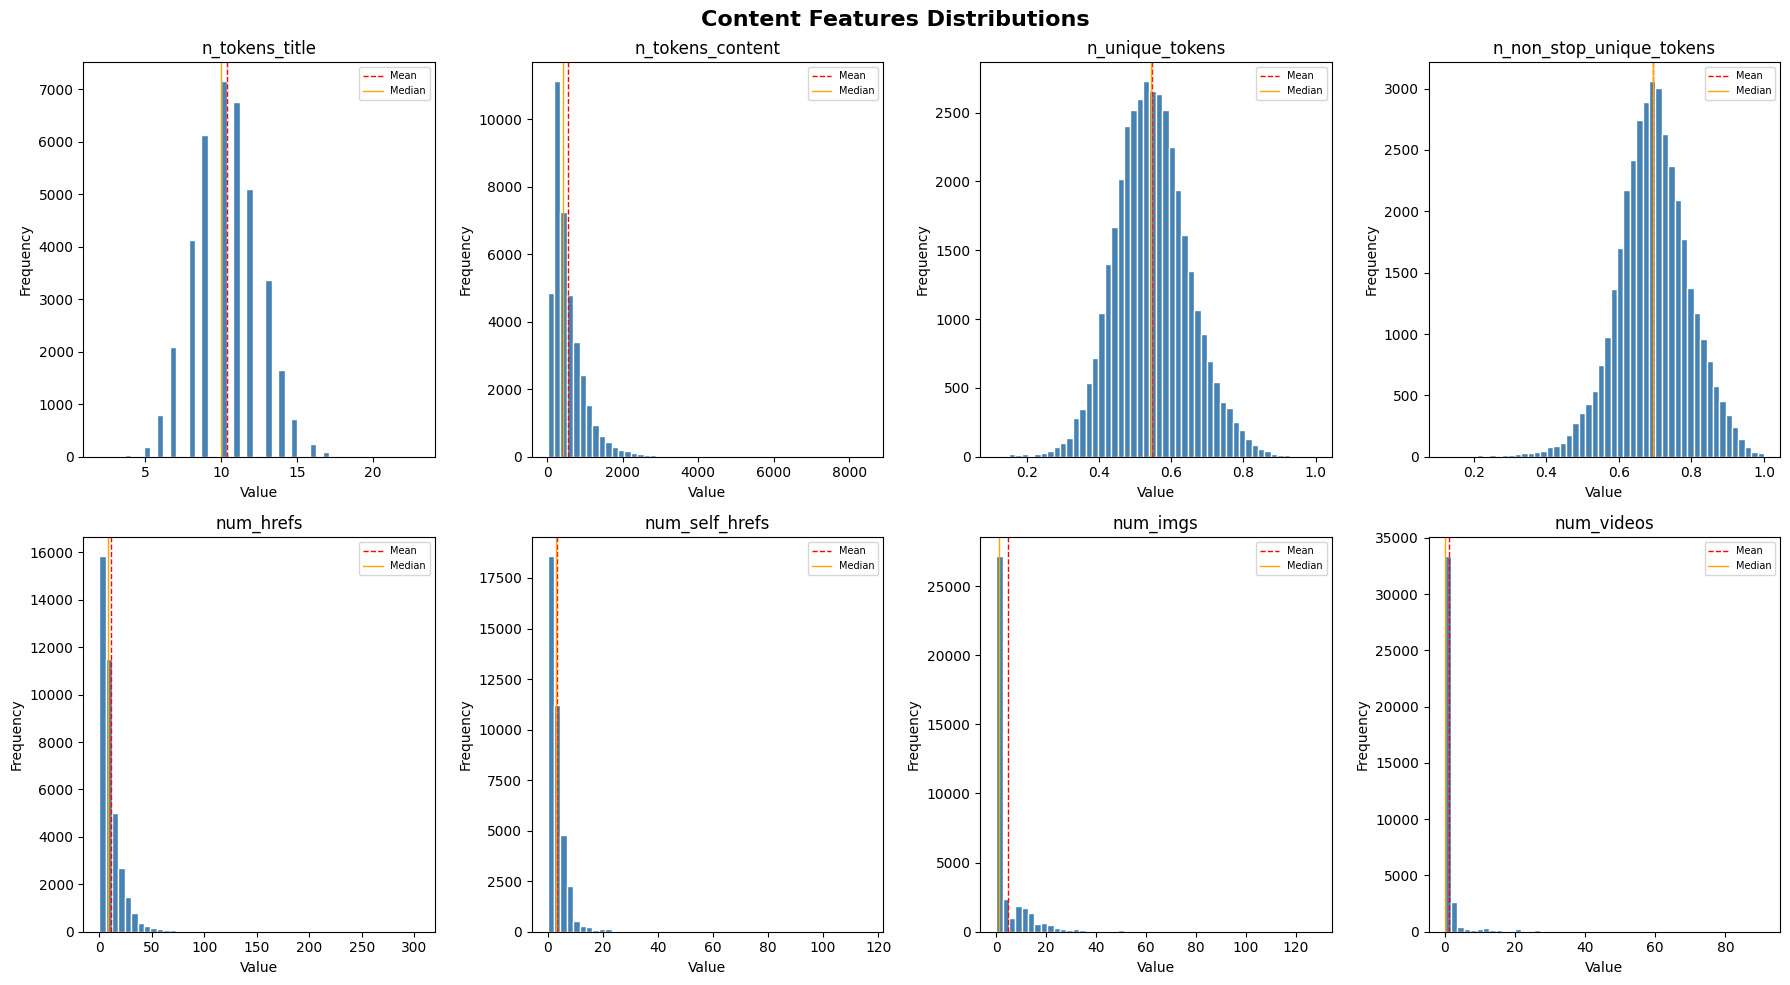

Content Features Statistics


,Feature,Mean,Median,Skewness
0,n_tokens_title,10.38,10.00,0.17
1,n_tokens_content,563.30,423.00,3.03
2,n_unique_tokens,0.55,0.54,0.18
3,n_non_stop_unique_tokens,0.69,0.69,-0.34
4,num_hrefs,11.22,8.00,4.07
5,num_self_hrefs,3.39,3.00,5.21
6,num_imgs,4.56,1.00,3.96
7,num_videos,1.26,0.00,6.93


In [ ]:
content_features = [
    'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
    'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs',
    'num_imgs', 'num_videos'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Content Features Distributions', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(content_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1, label='Median')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Content Features Statistics")
summary_table = pd.DataFrame({
    'Feature': content_features,
    'Mean': [df[col].mean() for col in content_features],
    'Median': [df[col].median() for col in content_features],
    'Skewness': [df[col].skew() for col in content_features]
})

summary_table.style\
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Skewness": "{:.2f}"
    })\
    .background_gradient(subset=["Skewness"], cmap="coolwarm")

### Sentiment Features Distributions

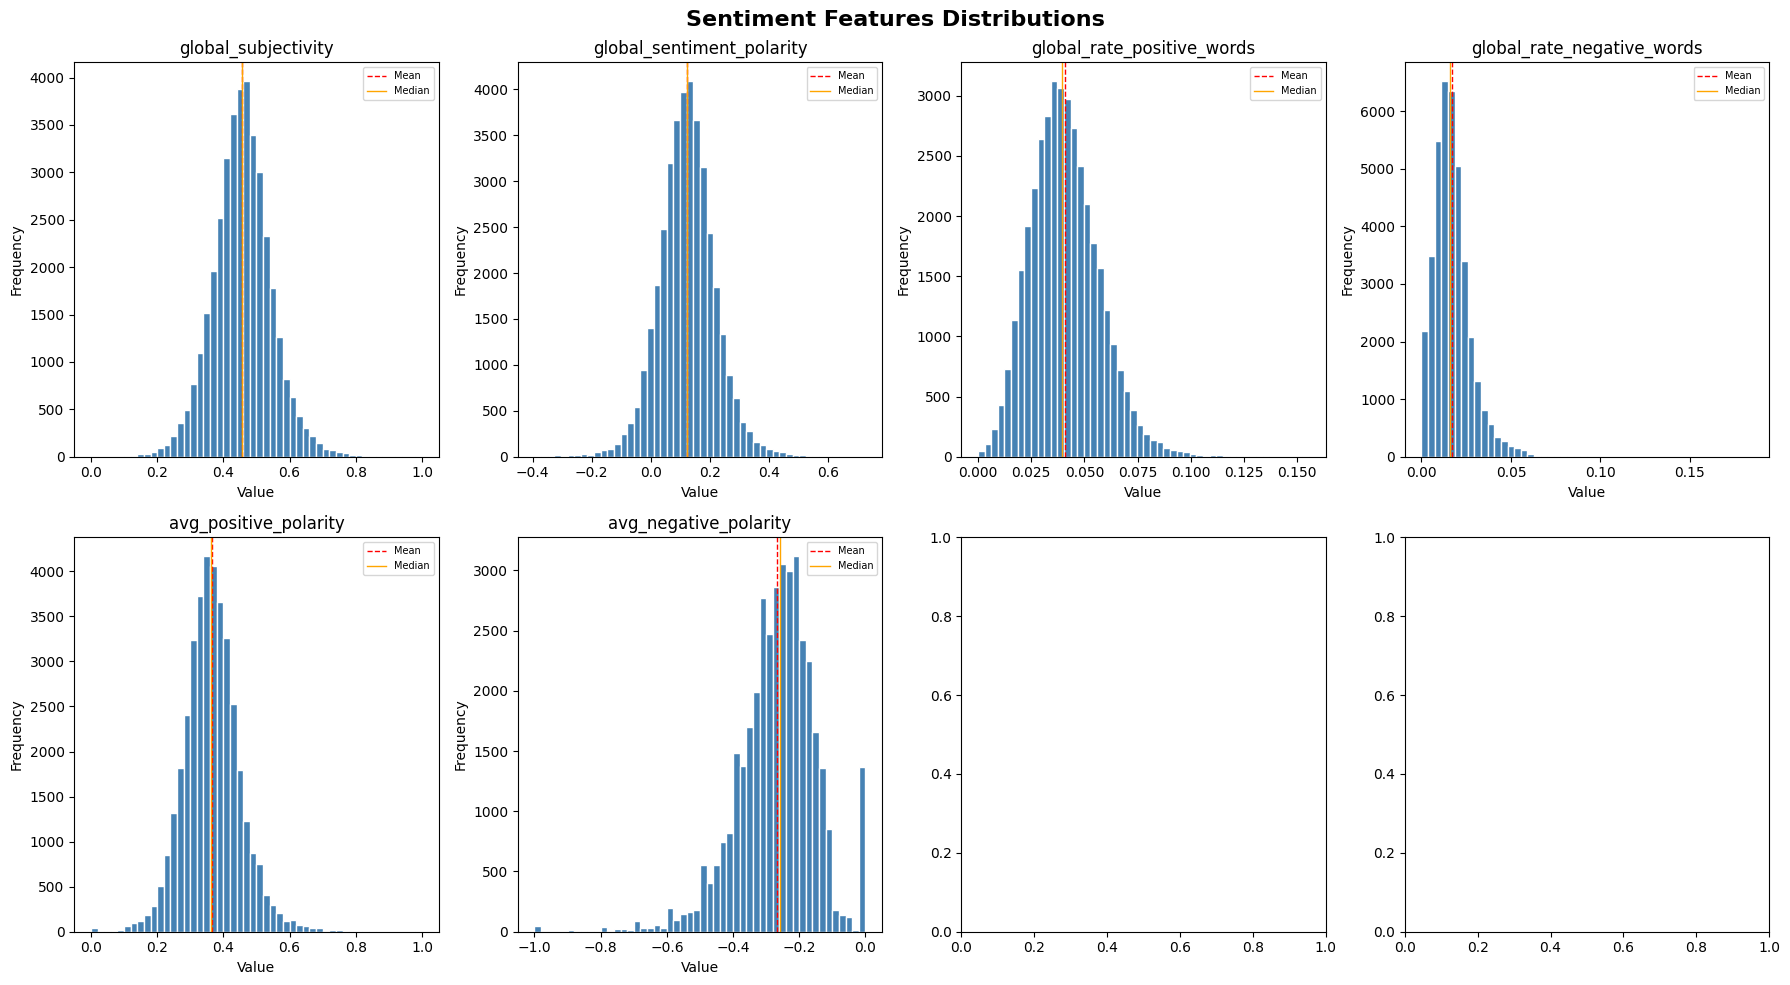

Sentiment Features Statistics


,Feature,Mean,Median,Skewness
0,global_subjectivity,0.46,0.46,0.15
1,global_sentiment_polarity,0.12,0.12,0.06
2,global_rate_positive_words,0.04,0.04,0.63
3,global_rate_negative_words,0.02,0.02,1.62
4,avg_positive_polarity,0.36,0.36,0.43
5,avg_negative_polarity,-0.27,-0.26,-0.77


In [ ]:
sentiment_features = [
    'global_subjectivity',
    'global_sentiment_polarity',
    'global_rate_positive_words',
    'global_rate_negative_words',
    'avg_positive_polarity',
    'avg_negative_polarity'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Sentiment Features Distributions', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(sentiment_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1, label='Median')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Sentiment Features Statistics")
summary_table = pd.DataFrame({
    'Feature': sentiment_features,
    'Mean': [df[col].mean() for col in sentiment_features],
    'Median': [df[col].median() for col in sentiment_features],
    'Skewness': [df[col].skew() for col in sentiment_features]
})

summary_table.style\
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Skewness": "{:.2f}"
    })\
    .background_gradient(subset=["Skewness"], cmap="coolwarm")

### Keyword Features Distributions

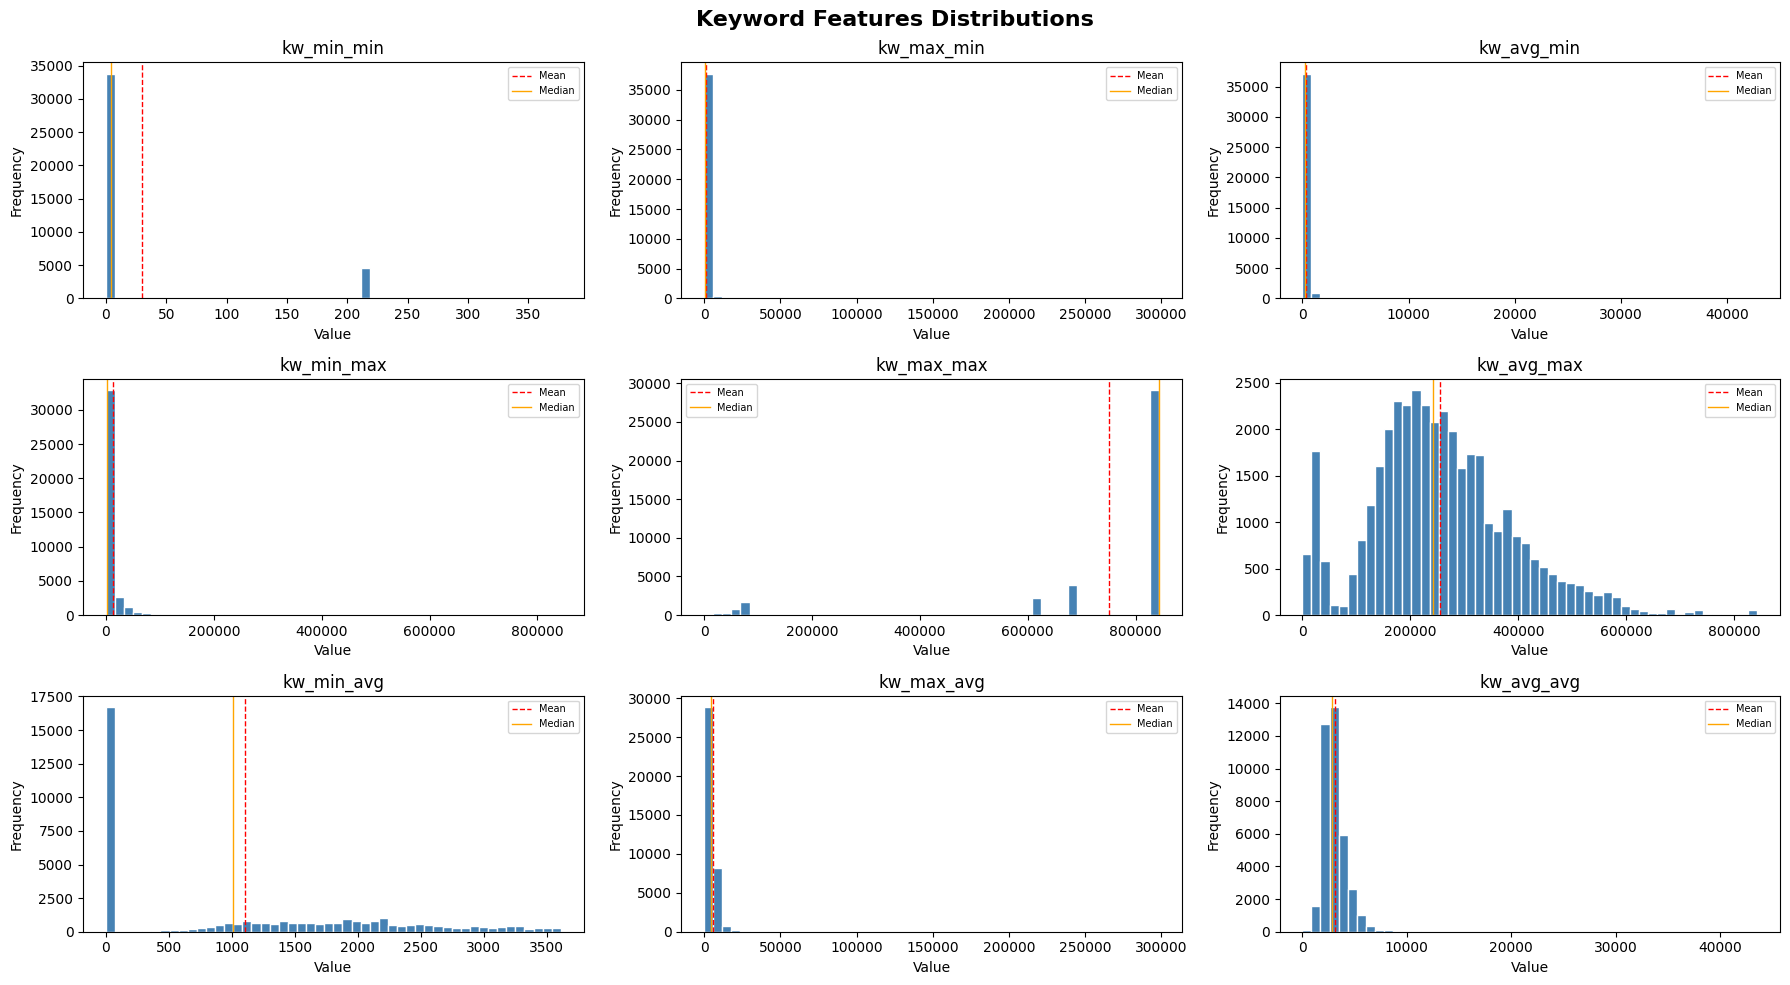

Keyword Features Statistics


,Feature,Mean,Median,Skewness
0,kw_min_min,29.56,4.00,2.34
1,kw_max_min,1151.75,660.00,35.84
2,kw_avg_min,318.21,241.33,31.75
3,kw_min_max,13182.55,1400.00,10.59
4,kw_max_max,750317.51,843300.00,-2.61
5,kw_avg_max,255215.16,242080.00,0.60
6,kw_min_avg,1102.14,1009.10,0.47
7,kw_max_avg,5603.78,4311.46,16.63
8,kw_avg_avg,3103.43,2850.85,6.07


In [ ]:
keyword_features = [
    'kw_min_min', 'kw_max_min', 'kw_avg_min',
    'kw_min_max', 'kw_max_max', 'kw_avg_max',
    'kw_min_avg', 'kw_max_avg', 'kw_avg_avg'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Keyword Features Distributions', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(keyword_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1, label='Median')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Keyword Features Statistics")
summary_table = pd.DataFrame({
    'Feature': keyword_features,
    'Mean': [df[col].mean() for col in keyword_features],
    'Median': [df[col].median() for col in keyword_features],
    'Skewness': [df[col].skew() for col in keyword_features]
})

summary_table.style\
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Skewness": "{:.2f}"
    })\
    .background_gradient(subset=["Skewness"], cmap="coolwarm")

### Channel Features Distributions

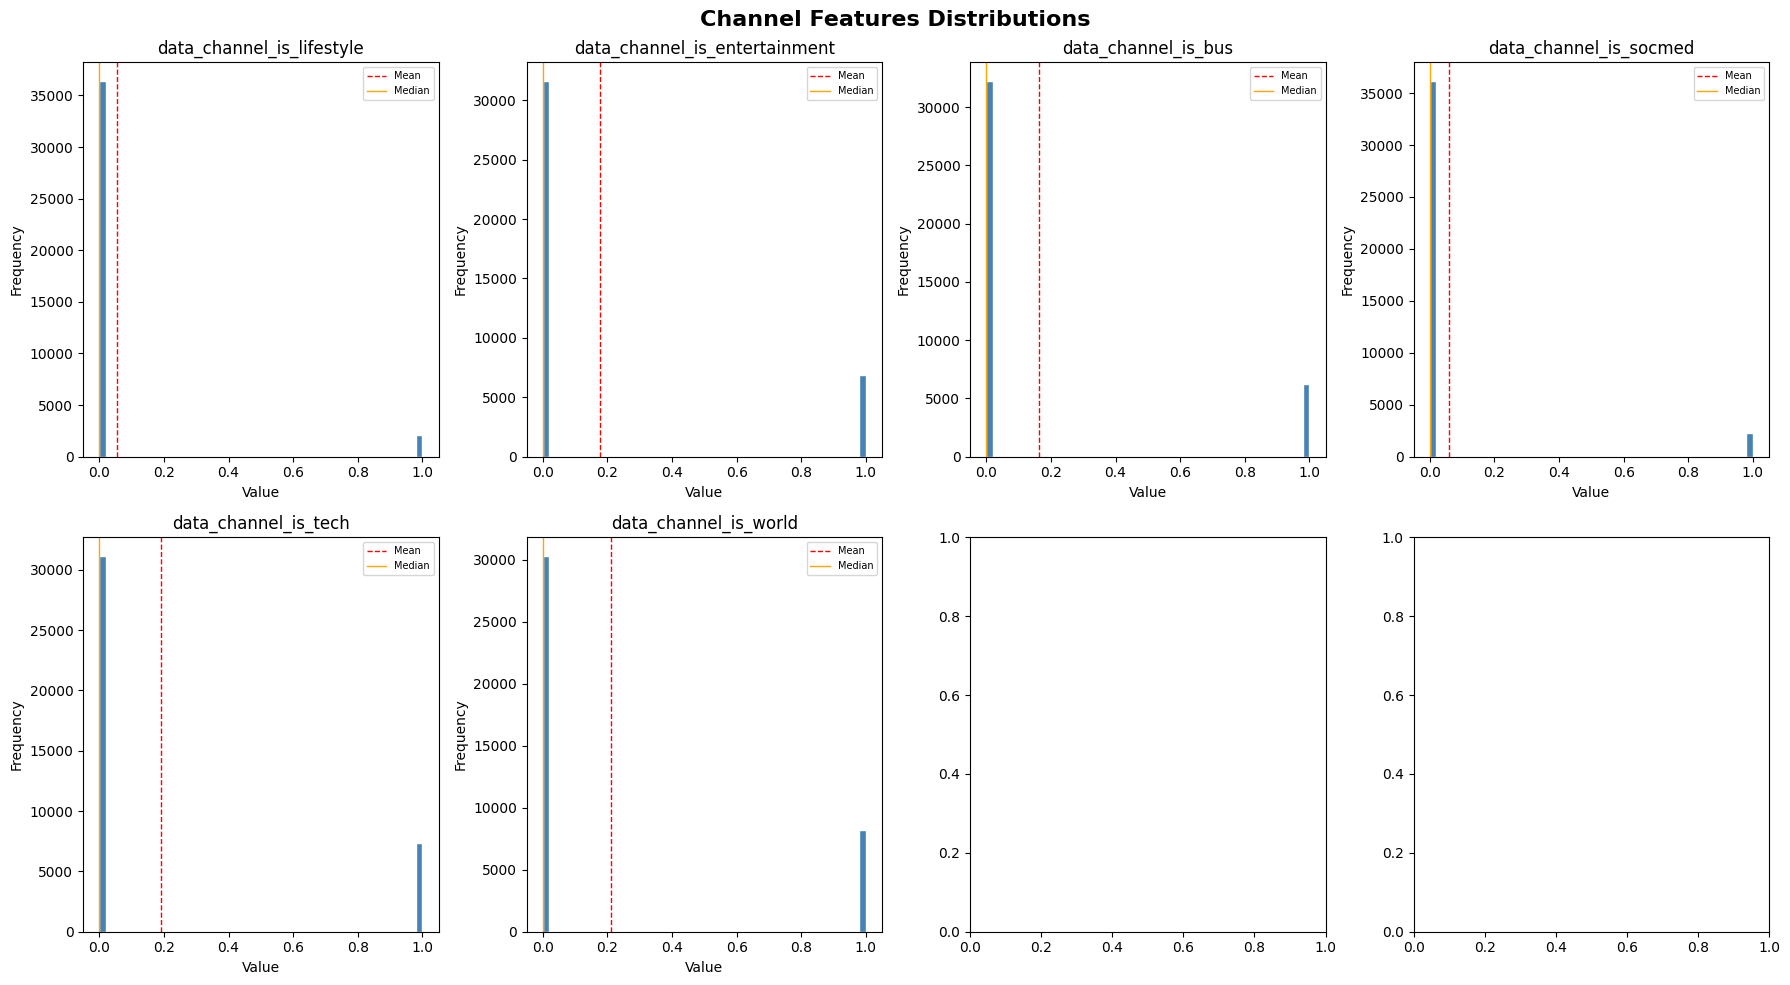

Channel Features Statistics


,Feature,Mean,Median,Skewness
0,data_channel_is_lifestyle,0.05,0.00,3.95
1,data_channel_is_entertainment,0.18,0.00,1.68
2,data_channel_is_bus,0.16,0.00,1.83
3,data_channel_is_socmed,0.06,0.00,3.70
4,data_channel_is_tech,0.19,0.00,1.58
5,data_channel_is_world,0.21,0.00,1.41


In [ ]:
channel_features = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Channel Features Distributions', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(channel_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=1, label='Median')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Channel Features Statistics")
summary_table = pd.DataFrame({
    'Feature': channel_features,
    'Mean': [df[col].mean() for col in channel_features],
    'Median': [df[col].median() for col in channel_features],
    'Skewness': [df[col].skew() for col in channel_features]
})

summary_table.style\
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Skewness": "{:.2f}"
    })\
    .background_gradient(subset=["Skewness"], cmap="coolwarm")

 #### Outlier Detection

In [ ]:
from IPython.display import display

# Quick skewness scan across all features
numeric_df = df.select_dtypes(include=['number'])

skewness = numeric_df.drop(columns=['shares']).skew().sort_values(ascending=False)

# Convert to proper table
skewness_df = skewness.reset_index()
skewness_df.columns = ['Feature', 'Skewness']

print("Highly Skewed Features (skewness > 1)")
high_skew = skewness_df[skewness_df['Skewness'] > 1]

display(
    high_skew.style
    .format({"Skewness": "{:.2f}"})
    .background_gradient(subset=["Skewness"], cmap="coolwarm")
)

print("Balanced Features (skewness <= 1)")
balanced = skewness_df[skewness_df['Skewness'] <= 1]

display(
    balanced.style
    .format({"Skewness": "{:.2f}"})
    .background_gradient(subset=["Skewness"], cmap="coolwarm")
)

Highly Skewed Features (skewness > 1)


,Feature,Skewness
0,kw_max_min,35.84
1,kw_avg_min,31.75
2,self_reference_min_shares,25.90
3,self_reference_avg_shares,17.68
4,kw_max_avg,16.63
5,self_reference_max_shares,13.68
6,kw_min_max,10.59
7,num_videos,6.93
8,kw_avg_avg,6.07
9,num_self_hrefs,5.21


Balanced Features (skewness <= 1)


,Feature,Skewness
36,title_subjectivity,0.83
37,global_rate_positive_words,0.63
38,kw_avg_max,0.60
39,average_token_length,0.58
40,rate_negative_words,0.51
41,kw_min_avg,0.47
42,avg_positive_polarity,0.43
43,title_sentiment_polarity,0.41
44,n_unique_tokens,0.18
45,n_tokens_title,0.17


### Outlier Analysis

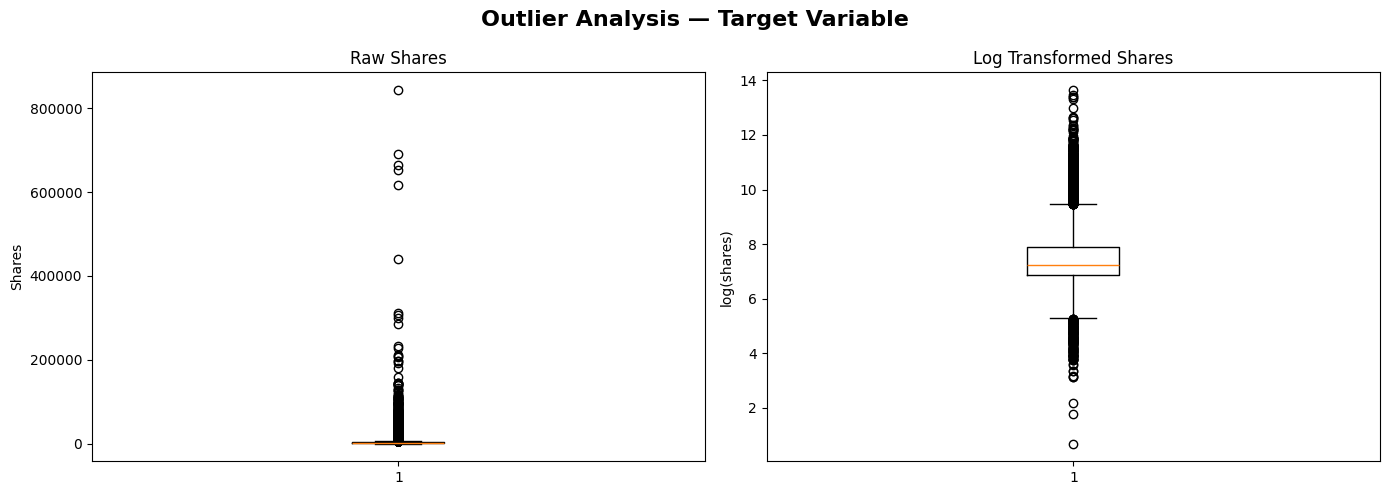

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Outlier Analysis — Target Variable', fontsize=16, fontweight='bold')

# Raw shares
axes[0].boxplot(df['shares'], vert=True)
axes[0].set_title('Raw Shares')
axes[0].set_ylabel('Shares')

# Log shares
axes[1].boxplot(np.log1p(df['shares']), vert=True)
axes[1].set_title('Log Transformed Shares')
axes[1].set_ylabel('log(shares)')

plt.tight_layout()
plt.show()

### Outlier Detection Using IQR Method

Outlier Detection (IQR Method)



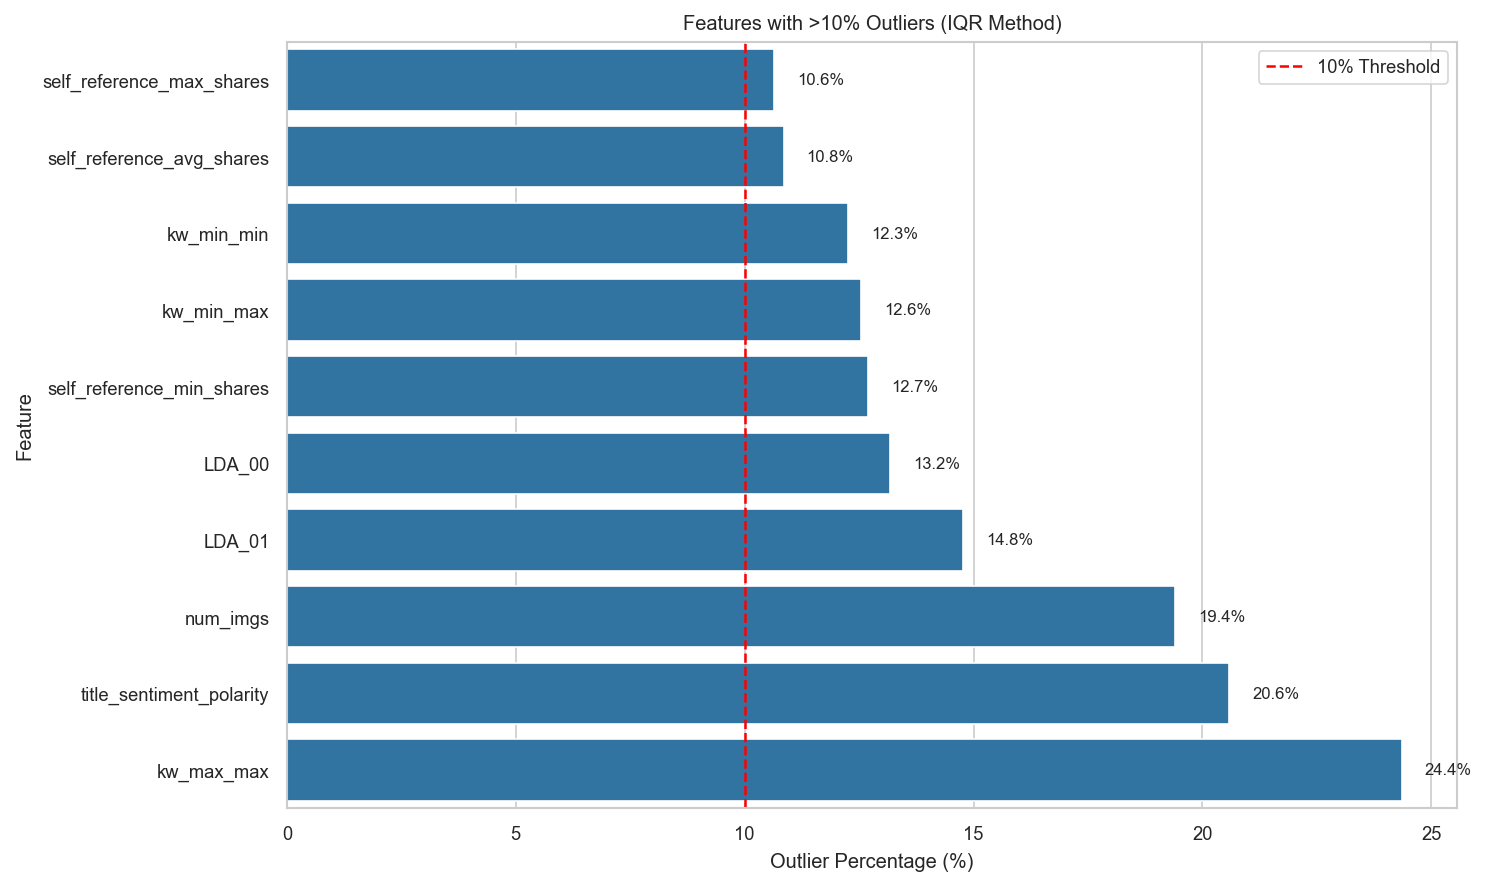

Features with >10% outliers:



,Feature,Outliers,Outlier %
16,kw_max_max,9365,24.35
42,title_sentiment_polarity,7918,20.59
8,num_imgs,7466,19.41
25,LDA_01,5682,14.77
24,LDA_00,5071,13.18
21,self_reference_min_shares,4884,12.70
15,kw_min_max,4827,12.55
12,kw_min_min,4717,12.26
23,self_reference_avg_shares,4175,10.85
22,self_reference_max_shares,4094,10.64


In [ ]:
# IQR outlier detection across all numeric features
print("Outlier Detection (IQR Method)\n")

outlier_summary = []

# Only check numeric non-binary columns
skip_cols = ['shares']
binary_cols = [c for c in df.columns if df[c].nunique() == 2]

check_cols = [c for c in df.select_dtypes(include=np.number).columns 
              if c not in skip_cols and c not in binary_cols]

for col in check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Outliers': n_outliers,
        'Outlier %': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)

high_outliers = outlier_df[outlier_df['Outlier %'] > 10]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=high_outliers.sort_values('Outlier %'),
    x='Outlier %',
    y='Feature'
)

plt.title('Features with >10% Outliers (IQR Method)')
plt.xlabel('Outlier Percentage (%)')
plt.ylabel('Feature')

# Add value labels
for i, v in enumerate(high_outliers.sort_values('Outlier %')['Outlier %']):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

# Threshold line
plt.axvline(10, color='red', linestyle='--', label='10% Threshold')

plt.legend()
plt.tight_layout()
plt.show()


print("Features with >10% outliers:\n")
display(
    high_outliers.style
    .format({"Outlier %": "{:.2f}"})
    .background_gradient(subset=["Outlier %"], cmap="coolwarm")
)

### Categorical Feature Analysis

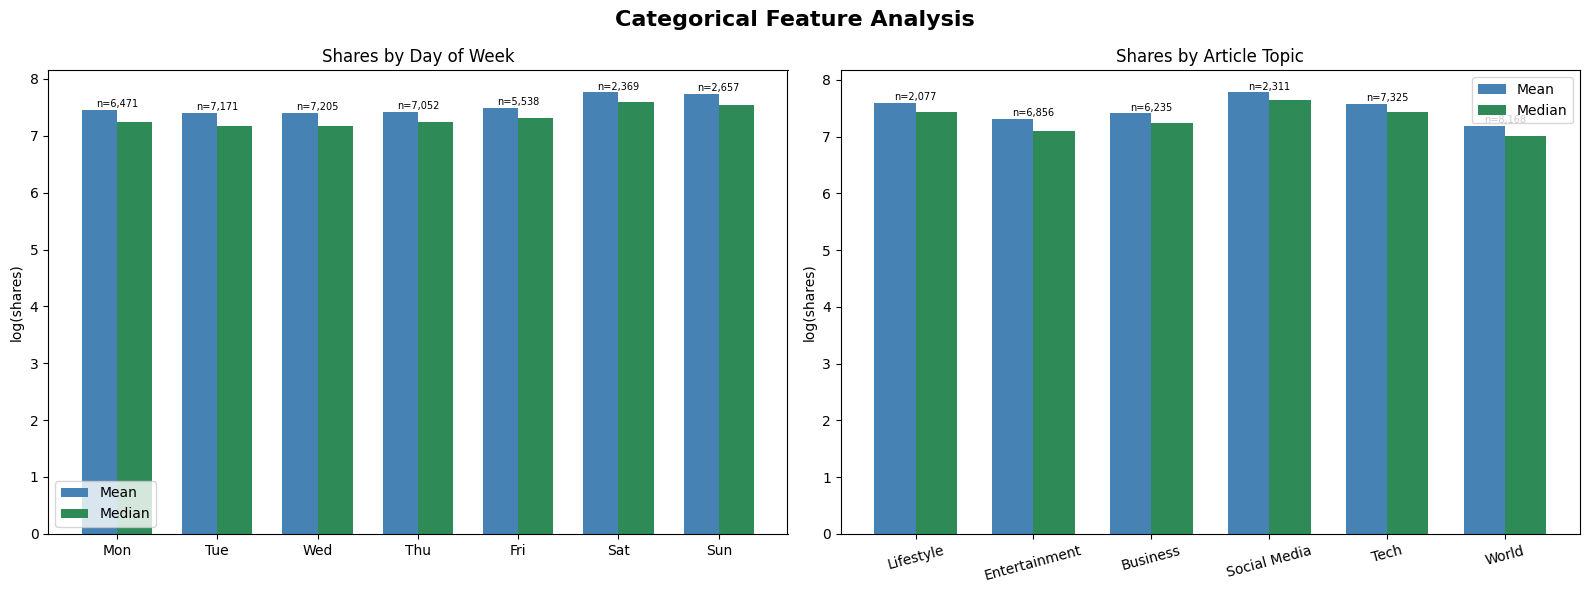

=== Shares by Day of Week ===

Mon: Mean=7.452 | Median=7.245 | Count=6,471
Tue: Mean=7.409 | Median=7.171 | Count=7,171
Wed: Mean=7.400 | Median=7.171 | Count=7,205
Thu: Mean=7.413 | Median=7.245 | Count=7,052
Fri: Mean=7.483 | Median=7.314 | Count=5,538
Sat: Mean=7.763 | Median=7.601 | Count=2,369
Sun: Mean=7.733 | Median=7.550 | Count=2,657

=== Shares by Article Topic ===

Lifestyle: Mean=7.598 | Median=7.439 | Count=2,077
Entertainment: Mean=7.309 | Median=7.091 | Count=6,856
Business: Mean=7.409 | Median=7.245 | Count=6,235
Social Media: Mean=7.779 | Median=7.650 | Count=2,311
Tech: Mean=7.581 | Median=7.439 | Count=7,325
World: Mean=7.193 | Median=7.004 | Count=8,168


In [ ]:
# Step 5 — Categorical Feature Analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Categorical Feature Analysis', fontsize=16, fontweight='bold')

# ---- Part 1: Shares by Day of Week ----
day_cols = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
    'weekday_is_sunday'
]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_means = []
day_medians = []
day_counts = []

for col in day_cols:
    subset = np.log1p(df[df[col] == 1]['shares'])
    day_means.append(subset.mean())
    day_medians.append(subset.median())
    day_counts.append(len(subset))

x = np.arange(len(day_labels))
width = 0.35

axes[0].bar(x - width/2, day_means, width, label='Mean', color='steelblue')
axes[0].bar(x + width/2, day_medians, width, label='Median', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(day_labels)
axes[0].set_title('Shares by Day of Week')
axes[0].set_ylabel('log(shares)')
axes[0].legend()

# Add count labels on top
for i, count in enumerate(day_counts):
    axes[0].text(i, max(day_means[i], day_medians[i]) + 0.05,
                f'n={count:,}', ha='center', fontsize=7)

# ---- Part 2: Shares by Article Topic ----
channel_cols = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
]
channel_labels = ['Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World']

channel_means = []
channel_medians = []
channel_counts = []

for col in channel_cols:
    subset = np.log1p(df[df[col] == 1]['shares'])
    channel_means.append(subset.mean())
    channel_medians.append(subset.median())
    channel_counts.append(len(subset))

x2 = np.arange(len(channel_labels))

axes[1].bar(x2 - width/2, channel_means, width, label='Mean', color='steelblue')
axes[1].bar(x2 + width/2, channel_medians, width, label='Median', color='seagreen')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(channel_labels, rotation=15)
axes[1].set_title('Shares by Article Topic')
axes[1].set_ylabel('log(shares)')
axes[1].legend()

for i, count in enumerate(channel_counts):
    axes[1].text(i, max(channel_means[i], channel_medians[i]) + 0.05,
                f'n={count:,}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

# Print summary stats
print("=== Shares by Day of Week ===\n")
for i, day in enumerate(day_labels):
    print(f"{day}: Mean={day_means[i]:.3f} | Median={day_medians[i]:.3f} | Count={day_counts[i]:,}")

print("\n=== Shares by Article Topic ===\n")
for i, channel in enumerate(channel_labels):
    print(f"{channel}: Mean={channel_means[i]:.3f} | Median={channel_medians[i]:.3f} | Count={channel_counts[i]:,}")

### Bivariate Analysis

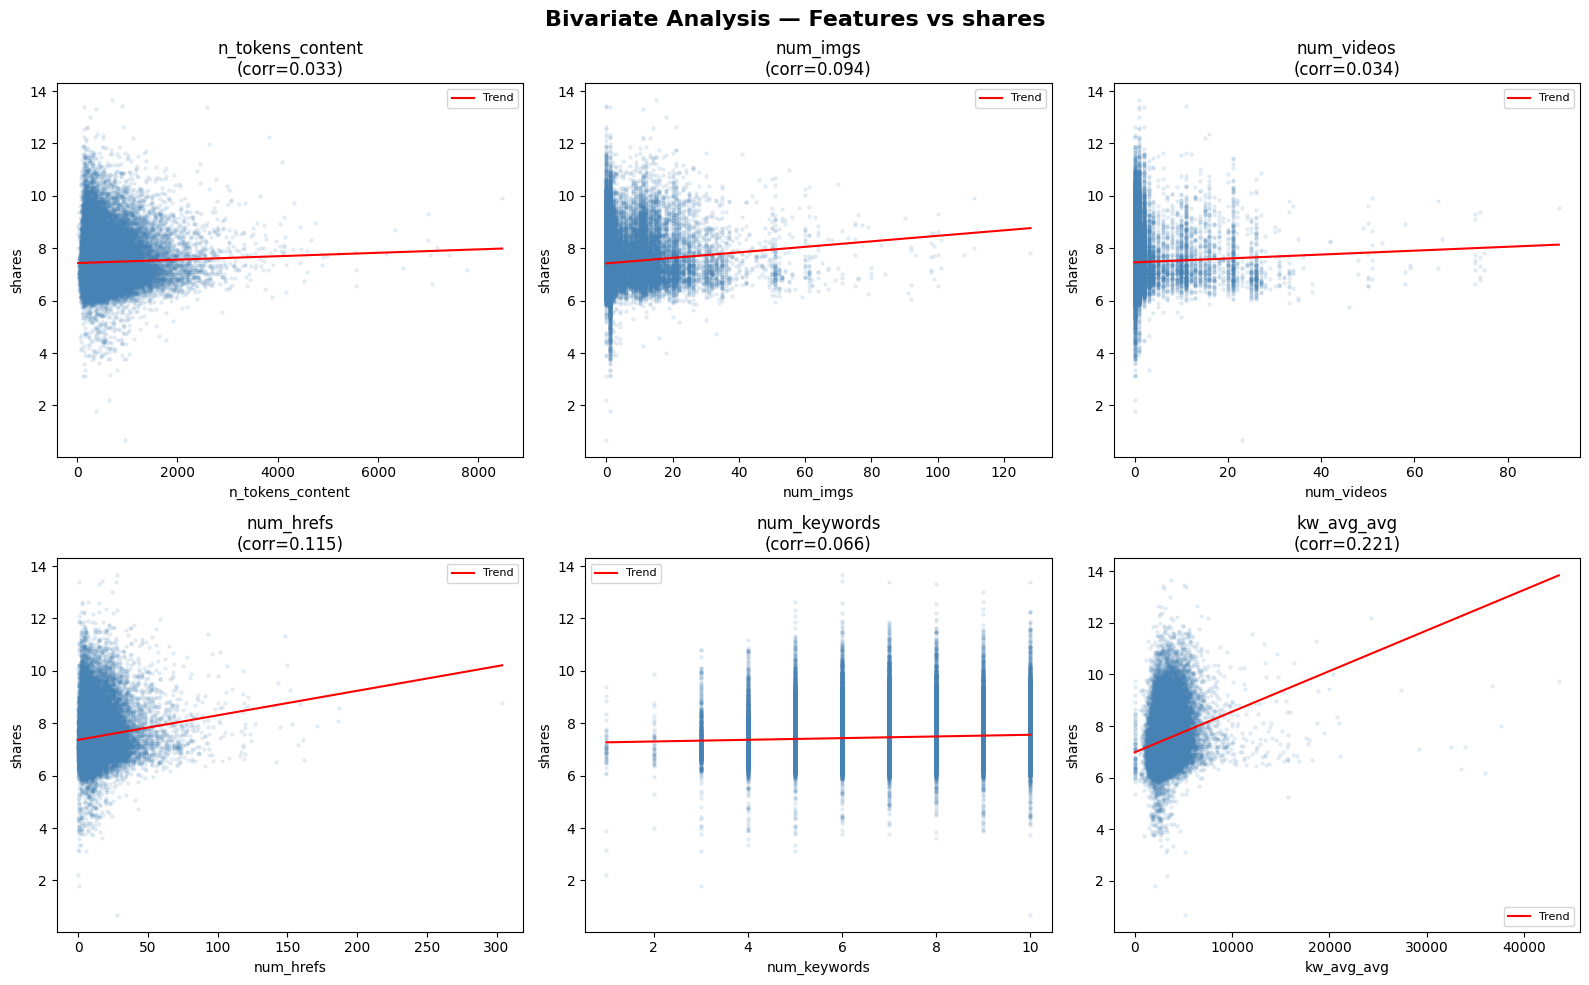

In [ ]:
features_to_plot = [
    'n_tokens_content', 'num_imgs', 'num_videos',
    'num_hrefs', 'num_keywords', 'kw_avg_avg'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bivariate Analysis — Features vs shares', 
             fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].scatter(df[col], np.log1p(df['shares']), 
                   alpha=0.1, color='steelblue', s=5)
    
    # Add trend line
    z = np.polyfit(df[col], np.log1p(df['shares']), 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[col])
    axes[i].plot(x_sorted, p(x_sorted), 
                color='red', linewidth=1.5, label='Trend')
    
    # Correlation value
    corr = df[col].corr(np.log1p(df['shares']))
    axes[i].set_title(f'{col}\n(corr={corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('shares')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Key Findings & Summary

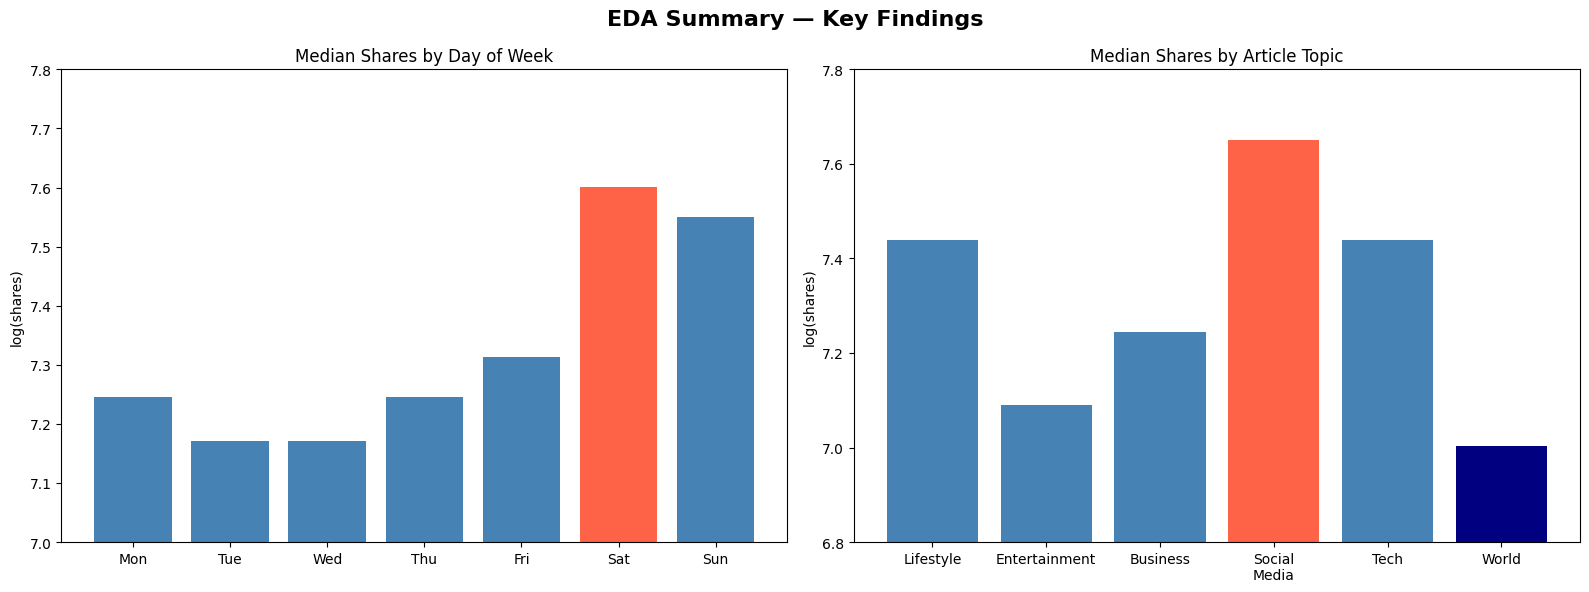

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Summary — Key Findings', fontsize=16, fontweight='bold')

# Shares by Day of Week 
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_cols = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
    'weekday_is_sunday'
]
day_medians = [np.log1p(df[df[col] == 1]['shares']).median() for col in day_cols]
colors_day = ['tomato' if d == max(day_medians) else 'steelblue' for d in day_medians]
axes[0].bar(day_labels, day_medians, color=colors_day)
axes[0].set_title('Median Shares by Day of Week')
axes[0].set_ylabel('log(shares)')
axes[0].set_ylim(7.0, 7.8)

# Shares by Topic 
channel_cols = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
]
channel_labels = ['Lifestyle', 'Entertainment', 'Business', 'Social\nMedia', 'Tech', 'World']
channel_medians = [np.log1p(df[df[col] == 1]['shares']).median() for col in channel_cols]
colors_ch = ['tomato' if c == max(channel_medians) else 
             'navy' if c == min(channel_medians) else 
             'steelblue' for c in channel_medians]
axes[1].bar(channel_labels, channel_medians, color=colors_ch)
axes[1].set_title('Median Shares by Article Topic')
axes[1].set_ylabel('log(shares)')
axes[1].set_ylim(6.8, 7.8)

plt.tight_layout()
plt.show()

### EDA Summary & Key Findings

#### 1. Target Variable
- shares is extremely right skewed (skewness = 34.95)
- Log transformation reduced skewness to 1.03
- shares_log confirmed as the target variable for regression
- Typical article gets ~1,400 shares (median)
- A small number of viral articles get 100,000+ shares

#### 2. Feature Distributions
- 36 features are highly skewed (skewness > 1) → need log transformation
- 21 features are balanced (skewness <= 1) → no transformation needed
- Binary features (weekday, channel) are expected to be skewed → no action needed

#### 3. Outliers
- 10 features have >10% outliers
- Most problematic: kw_max_max (24%), title_sentiment_polarity (21%), num_imgs (19%)
- Outliers are real data points, not errors → handle via transformation and scaling

#### 4. Correlations
- Most features have weak correlation with shares_log → predicting shares is hard
- 8 highly correlated feature pairs (>0.8) identified → drop one from each pair
- Most critical: rate_positive_words & rate_negative_words (corr = -0.997)

#### 5. Categorical Features
- Weekend articles outperform weekdays (Saturday best)
- Social Media and Lifestyle topics get most shares
- World news gets fewest shares despite being most produced

#### 6. Bivariate Analysis
- kw_avg_avg is strongest predictor → popular keywords = more shares
- More images = more shares consistently
- Very short (<231 words) or very long (>824 words) articles outperform medium length
- 16+ links associated with higher shares

#### 7. Features to Drop in Feature Engineering
- rate_negative_words (corr = -0.997 with rate_positive_words)
- self_reference_min_shares (redundant with avg)
- self_reference_max_shares (redundant with avg)
- kw_max_min (corr = 0.94 with kw_avg_min)
- kw_max_avg (corr = 0.816 with kw_avg_avg)
- n_non_stop_unique_tokens (corr = 0.885 with n_unique_tokens)

#### 8. Features to Log Transform in Feature Engineering
- n_tokens_content, num_hrefs, num_self_hrefs
- num_imgs, num_videos
- kw_max_min, kw_avg_min, kw_min_max
- self_reference_min/max/avg_shares